# Gradient Boosting Model for Student Marks Prediction

## Objective

This notebook extends the existing student marks prediction project by:
- implementing a Gradient Boosting Regressor,
- using cross-validation,
- tuning model hyperparameters,
- evaluating the model using RMSE, MAE, and R²,
- and comparing its performance with the existing models.

In [2]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load the mathematics dataset
data_path = "../data/student-mat.csv"
df = pd.read_csv(data_path, sep=";")

print("Dataset successfully loaded!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset successfully loaded!
Rows: 395
Columns: 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Separate features (X) and target (y)

X = df.drop("G3", axis=1)
y = df["G3"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget variable (G3) summary:")
print(y.describe())

Features shape: (395, 32)
Target shape: (395,)

Target variable (G3) summary:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [5]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Number of numerical features: 15
Number of categorical features: 17

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Preprocessing:
# - Keep numerical features as they are
# - Convert categorical features into numerical columns using One-Hot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [7]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [8]:
#building Gradient Boosting model.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Create the Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Combine preprocessing + model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", gradient_boosting_model)
    ]
)

print("Gradient Boosting model created successfully!")

Gradient Boosting model created successfully!


In [9]:
# Train the Gradient Boosting model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [10]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[ 8.63863857 11.956774    6.02092068  9.92514872  9.04861078 12.79467987
 17.96007276  7.41426816  5.81083527 12.91703064]


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Gradient Boosting Model Performance")
print("-----------------------------------")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Gradient Boosting Model Performance
-----------------------------------
MAE  : 1.134
RMSE : 1.947
R²   : 0.815


In [12]:
from sklearn.model_selection import KFold, cross_val_score

# Create 5 folds
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the model using 5-fold cross-validation
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

# Convert negative MSE to RMSE
cv_rmse_scores = np.sqrt(-cv_scores)

print("5-Fold Cross-Validation Results")
print("--------------------------------")
print("RMSE for each fold:")

for i, score in enumerate(cv_rmse_scores, start=1):
    print(f"Fold {i}: {score:.3f}")

print(f"\nMean CV RMSE: {cv_rmse_scores.mean():.3f}")
print(f"Standard Deviation: {cv_rmse_scores.std():.3f}")

5-Fold Cross-Validation Results
--------------------------------
RMSE for each fold:
Fold 1: 1.947
Fold 2: 1.603
Fold 3: 1.131
Fold 4: 1.561
Fold 5: 1.914

Mean CV RMSE: 1.631
Standard Deviation: 0.295


In [13]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters we want to test
param_grid = {
    "regressor__n_estimators": [50, 100, 150],
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [2, 3, 4]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

print("Hyperparameter tuning setup completed!")

Hyperparameter tuning setup completed!


In [14]:
# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Hyperparameter tuning completed!


In [15]:
# Display the best hyperparameters
print("Best hyperparameters:")
print(grid_search.best_params_)

Best hyperparameters:
{'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 150}


In [16]:
# Get the best tuned model
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_tuned = best_model.predict(X_test)

# Calculate metrics
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Gradient Boosting Model Performance")
print("------------------------------------------")
print(f"MAE  : {mae_tuned:.3f}")
print(f"RMSE : {rmse_tuned:.3f}")
print(f"R²   : {r2_tuned:.3f}")

Tuned Gradient Boosting Model Performance
------------------------------------------
MAE  : 1.138
RMSE : 1.988
R²   : 0.807


## Model Comparison

The tuned Gradient Boosting model is compared with the other models developed in the project using MAE, RMSE, and R².

In [17]:
# Compare the models developed in the project

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Hurdle Model",
        "MLP",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        1.647,
        1.635,
        1.189,
        1.141,
        2.043,
        mae_tuned
    ],
    "RMSE": [
        2.378,
        2.368,
        1.958,
        2.097,
        2.654,
        rmse_tuned
    ],
    "R²": [
        0.724,
        0.726,
        0.813,
        0.786,
        0.656,
        r2_tuned
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.647000,2.378000,0.72400
1,Ridge Regression,1.635000,2.368000,0.72600
2,Random Forest,1.189000,1.958000,0.81300
3,Hurdle Model,1.141000,2.097000,0.78600
4,MLP,2.043000,2.654000,0.65600
5,Tuned Gradient Boosting,1.138417,1.987847,0.80729


### Interpretation

The tuned Gradient Boosting model achieved an MAE of 1.138, RMSE of 1.988, and R² of 0.807 on the test set.

Hyperparameter tuning selected 150 estimators, a learning rate of 0.05, and a maximum tree depth of 3.

The results show that tuning the Gradient Boosting model produced a model with competitive predictive performance compared with the other models evaluated in the project. The model's performance should be interpreted together with the cross-validation results rather than relying only on a single train-test split.

## Model Performance Comparison

The following visualization compares the RMSE of the models evaluated in this project. Lower RMSE indicates smaller prediction errors.

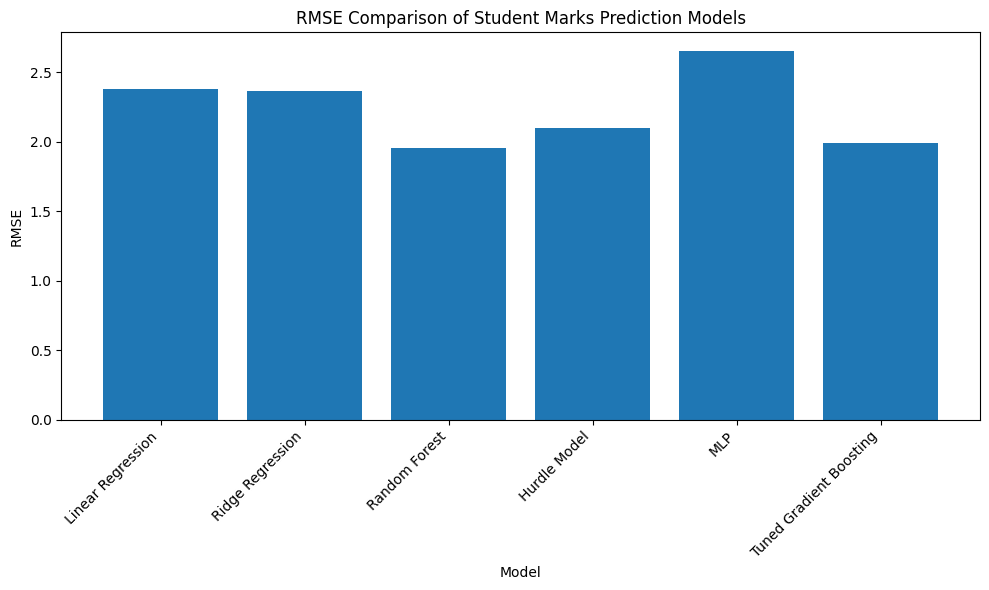

In [18]:
# Plot RMSE comparison

plt.figure(figsize=(10, 6))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison of Student Marks Prediction Models")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()